<h1><center>Churn Prediction (Statistical Testing, Stacking Ensemble) </center></h1>

<center><img src="https://uploads-ssl.webflow.com/60d45d63543dd9baaad4cb28/60d85fd90743e2299c711be5_1%20dqSLRSEC2GDV9bw_PplCYQ.png" align="center"/></center>

<a id='5'></a>
# 5 Univariate Analysis

<a id='5.1'></a>
## 5.1 Statistical Normality Tests

Normality tests are used to determine if a dataset is normally distributed and to check how likely it is for a random variable in the dataset to be normally distributed.

Popular normality tests -  D’Agostino’s K^2, Shapiro-Wilk, Anderson-Darling .

There are three numerical features in this dataset - **MonthlyCharges**, **Tenure**, and **TotalCharges**.


Hypotheses -

* H0: the sample has a Gaussian distribution.
* H1: the sample does not have a Gaussian distribution.

NB : we can not perform **Shapiro-Wilk Test** because sample size > 5000 and for this test p-value may not be accurate for N > 5000

<a id='5.1.1'></a>
### 5.1.1 D’Agostino’s K^2 Test

#### MonthlyCharges

In [26]:
stat, p = stats.normaltest(df_churn['MonthlyCharges'])

print('Statistics=%.5f, p=%.3f' % (stat, p))

# interpret
alpha = 0.05
if p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

Statistics=11419.52879, p=0.000
Sample does not look Gaussian (reject H0)


#### Tenure

In [27]:
stat, p = stats.normaltest(df_churn['tenure'])

print('Statistics=%.5f, p=%.3f' % (stat, p))

# interpret
alpha = 0.05
if p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

Statistics=76258.50517, p=0.000
Sample does not look Gaussian (reject H0)


<a id='5.1.2'></a>
### 5.1.2 Anderson-Darling Test

Hypotheses -

* H0: the sample has a Gaussian distribution
* H1: the sample does not have a Gaussian distribution

<br>


Critical values in a statistical test are a range of pre-defined significance boundaries at which the H0 can be failed to be rejected if the calculated statistic is less than the critical value. \
Rather than just a single p-value, the test returns a critical value for a **range of different commonly used significance levels**. \
In this case  - **normal/exponential** (15%, 10%, 5%, 2.5%, 1%)

#### TotalCharges

In [28]:
result = stats.anderson(df_churn['TotalCharges'])

print('Statistic: %.3f' % result.statistic)

p = 0

for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print(f'Significance level {sl:.2f} % : critical value {cv:.3f}, data looks normal (fail to reject H0)')
	else:
		print(f'Significance level {sl:.2f} % : critical value {cv:.3f}, data does not look normal (reject H0)')

Statistic: 346.638
Significance level 15.00 % : critical value 0.576, data does not look normal (reject H0)
Significance level 10.00 % : critical value 0.656, data does not look normal (reject H0)
Significance level 5.00 % : critical value 0.787, data does not look normal (reject H0)
Significance level 2.50 % : critical value 0.917, data does not look normal (reject H0)
Significance level 1.00 % : critical value 1.091, data does not look normal (reject H0)


<a id='5.2'></a>
## 5.2 Visualization

### Churn (Target) Distribution

In [29]:
vc = df_churn['Churn'].value_counts().reset_index(name='count') \
                      .rename(columns={'index': 'Churn'})  
# Now vc has columns: ['Churn', 'count']

# Plot pie chart
fig = px.pie(
    vc, 
    values='count', 
    names='Churn', 
    title='Churn (Target) Distribution'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# Print markdown note
printmd("### Target distribution is Imbalanced")


### Target distribution is Imbalanced

### OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport

In [30]:
# Create subplots: use 'domain' type for Pie subplot
fig = make_subplots(rows=2, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}],[{'type':'domain'}, {'type':'domain'}]])

fig.add_trace(go.Pie(labels=df_churn['OnlineSecurity'].value_counts().index, values=df_churn['OnlineSecurity'].value_counts().values, name="Online Security"),
              1, 1)
fig.add_trace(go.Pie(labels=df_churn['OnlineBackup'].value_counts().index, values=df_churn['OnlineBackup'].value_counts().values, name="Online Backup"),
              1, 2)
fig.add_trace(go.Pie(labels=df_churn['DeviceProtection'].value_counts().index, values=df_churn['DeviceProtection'].value_counts().values, name="Device Protection"),
              2, 1)
fig.add_trace(go.Pie(labels=df_churn['TechSupport'].value_counts().index, values=df_churn['TechSupport'].value_counts().values, name="Tech Support"),
              2, 2)

# donut-like pie chart
fig.update_traces(hole=.5, hoverinfo="label+percent")

fig.update_layout(

    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Online<br>Security', x=0.195, y=0.85, font_size=20, showarrow=False),
                 dict(text='Online<br>Backup', x=0.805, y=0.84, font_size=20, showarrow=False),
                 dict(text='Device<br>Protection', x=0.185, y=0.18, font_size=20, showarrow=False),
                 dict(text='Tech<br>Support', x=0.805, y=0.18, font_size=20, showarrow=False)])
fig.update_layout(margin=dict(t=0, b=0, l=0, r=0))
fig.show()



printmd("### 'Online Backup', 'Device Protection' and 'Online Security', 'Tech Support' has similar distribution")

### 'Online Backup', 'Device Protection' and 'Online Security', 'Tech Support' has similar distribution

### PaymentMethod

In [31]:
display(px.pie(df_churn['PaymentMethod'].value_counts().reset_index(name='count').rename(columns={'index':'PaymentMethod'}),
               values='count', names='PaymentMethod', title='Payment Method Distribution'))

printmd("#### Most of the customers use E-check")


#### Most of the customers use E-check

### Gender

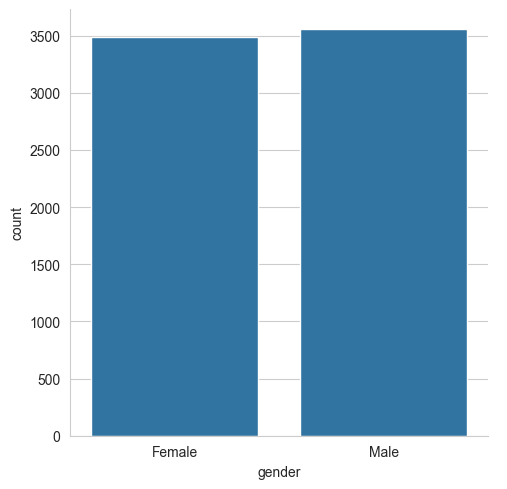

#### Approximately 50/50 gender ratio

In [32]:
sns.catplot(x="gender", kind="count", data=df_churn)
plt.show()

printmd("#### Approximately 50/50 gender ratio")

### Dependents

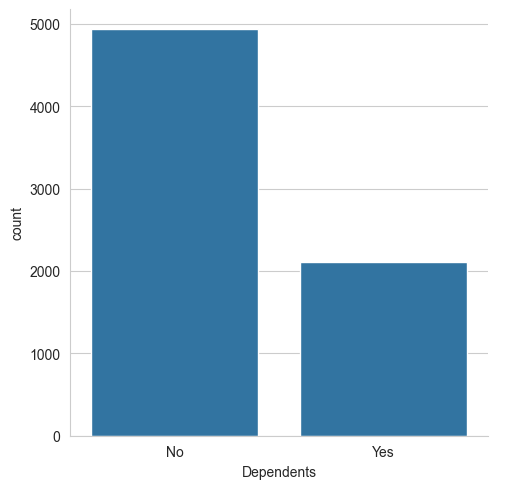

#### Users who have non-dependents are approximately two times more than users having dependents

In [33]:
sns.catplot(x="Dependents", kind="count", data=df_churn)
plt.show()

printmd("#### Users who have non-dependents are approximately two times more than users having dependents")

### Senior Citizen

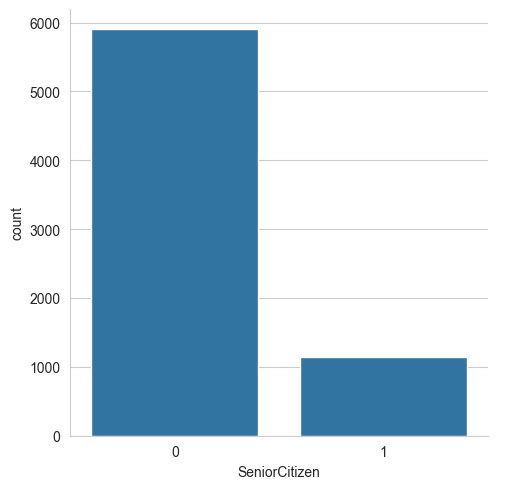

#### The majority of the users are not Senior Citizen

In [34]:
sns.catplot(x="SeniorCitizen", kind="count", data=df_churn)
plt.show()

printmd("#### The majority of the users are not Senior Citizen")

### Contract

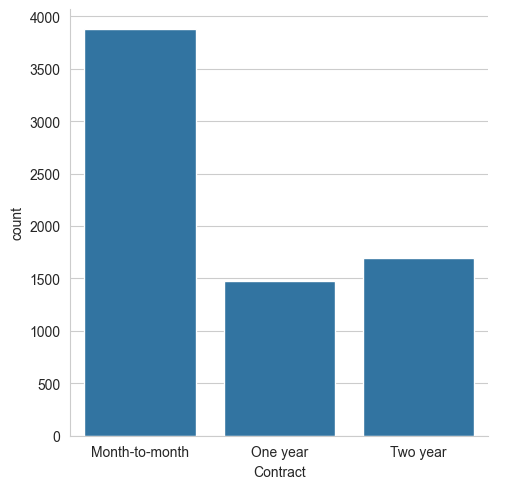

#### Most of the users prefer Month-to-month contract

In [35]:
sns.catplot(x="Contract", kind="count", data=df_churn)
plt.show()

printmd("#### Most of the users prefer Month-to-month contract")

### PaperlessBilling

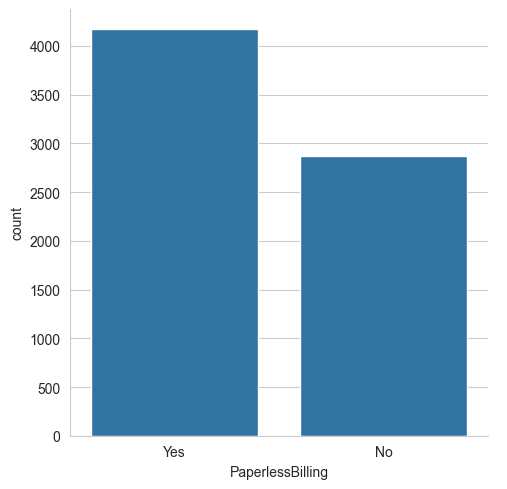

#### Most of the users prefer paperless billing

In [36]:
sns.catplot(x="PaperlessBilling", kind="count", data=df_churn)
plt.show()

printmd("#### Most of the users prefer paperless billing")

### Total Charges

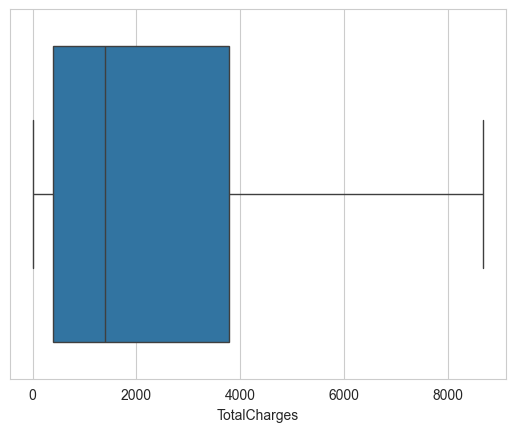

#### The total charges fall under 4000 for majority of the users

In [37]:
sns.boxplot(x=df_churn["TotalCharges"])
plt.show()

printmd("#### The total charges fall under 4000 for majority of the users")

### Numerical Features

In [38]:
"""#1.Create a function to plot histogram and density plot."""
def plot_histogram(feature):
    """Plots histogram and density plot of a variable."""
    
    # Create subplot object
    fig = make_subplots(
        rows=2,
        cols=1,
        print_grid=False,
    subplot_titles=(f"Distribution of {feature.name} with Histogram", f"Distribution of {feature.name} with Density Plot"))
    
    # This is a count histogram
    fig.add_trace(
        go.Histogram(
            x = feature,
            hoverinfo="x+y"
        ),
    row=1,col=1)

    # This is a density histogram
    fig.add_trace(
        go.Histogram(
            x = feature,
            hoverinfo="x+y",
            histnorm = "density"
        ),
    row=2,col=1)
    
    # Update layout
    fig.layout.update(
        height=800, 
        width=870,
        hovermode="closest"
        )
    
    # Update axes
    fig.layout.yaxis1.update(title="<b>Abs Frequency</b>")
    fig.layout.yaxis2.update(title="<b>Density(%)</b>")
    fig.layout.xaxis2.update(title=f"<b>{feature.name}</b>")
    return fig.show()

In [39]:
plot_histogram(df_churn['tenure'])

printmd("**Tenure is U-shaped distributed**")

**Tenure is U-shaped distributed**

In [40]:
plot_histogram(df_churn['MonthlyCharges'])

printmd("**MonthlyCharges is heavily skewed**")

**MonthlyCharges is heavily skewed**

In [41]:
plot_histogram(df_churn['TotalCharges'])

printmd("**TotalCharges is reversed J-shaped distributed**")

**TotalCharges is reversed J-shaped distributed**